## Kütüphanelerin İçe Aktarılması

Bu hücre, projemizde kullanacağımız temel Python kütüphanelerini içe aktarır:
- `idx2numpy`: MNIST veri setinin özel formatını (`.idx3-ubyte`, `.idx1-ubyte`) okumak için kullanılır.
<span style="color:red">- **`numpy`: Sayısal işlemler, özellikle diziler (array) üzerinde matematiksel operasyonlar için temel kütüphanedir.**</span>
- `collections.Counter`: Bir listedeki elemanların frekanslarını saymak için kullanılır. KNN'de en yakın komşuların sınıflarını sayıp en sık görüneni bulmak için kullanışlıdır.
- `matplotlib.pyplot`: Veri görselleştirme, özellikle MNIST görüntülerinin çizdirilmesi için kullanılır.

In [9]:
import idx2numpy
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

### MNIST Veri Setinin İndirilmesi ve Açılması

Bu hücre, MNIST veri setini içeren zip dosyasını indirir ve `m_nist` adlı bir klasöre açar.

- `!wget`: Web'den dosya indirmek için kullanılan bir komut satırı aracıdır.
- `!unzip`: Zip arşivini açmak için kullanılan bir komut satırı aracıdır.

*Not: Bu komutlar genellikle Google Colab veya benzeri Linux tabanlı ortamlarda çalışır. Yerel makinenizde çalıştırıyorsanız, bu adımları manuel olarak yapmanız veya işletim sisteminize uygun komutları kullanmanız gerekebilir.*

In [10]:
!wget https://github.com/ihpar/ibu_cv/raw/main/mnist/m_nist.zip
!unzip /content/m_nist.zip -d m_nist



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://github.com/ihpar/ibu_c]87m_nist.zip             0% [<=>                           ]       0          B/s87HTTP response 302  [https://github.com/ihpar/ibu_cv/raw/main/mnist/m_nist.zip]
87m_nist.zip             0% [ <=>                          ]       0          B/s87Adding URL: https://raw.githubusercontent.com/ihpar/ibu_cv/main/mnist/m_nist.zip
87[Files: 0  Bytes: 0  [0 B/s] Re]87[Files: 0  Bytes: 0  [0 B/s] Re]87[https://raw.githubusercontent.]87Saving 'm_nist.zip.1'
87m_nist.zip.1           0% [>                             ]   55.66K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87m_nist.zip.1          39% [==========>                   ]    3.67M    3.61MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87m_nist.zip.1         100% [=============================>]    9.39M    4.79MB/s87HTTP response 200  [https://raw.githubusercontent.com/ihpar/ibu_cv/main/mnist/m_nist.zip]
87m_nist.zip.1         100% [==============

### Veri Seti Dizininin Tanımlanması

MNIST veri setinin bulunduğu dizinin yolunu bir değişkende saklarız. Bu, kodun ilerleyen kısımlarında dosya yollarına erişimi kolaylaştırır.

In [11]:
MNIST_DIR = "mnist/"

### Veri Setinin Yüklenmesi ve İncelenmesi

Bu hücre, MNIST veri setini yüklemek ve temel özelliklerini incelemek için kullanılır. MNIST veri seti, el yazısı rakamların görüntülerinden oluşan bir veri setidir ve makine öğrenimi ve derin öğrenme projelerinde yaygın olarak kullanılır.

#### Kullanılan Kütüphaneler ve Fonksiyonlar
- **`idx2numpy`**: MNIST veri setinin özel `.idx` formatındaki dosyalarını NumPy dizilerine dönüştürmek için kullanılır.
- **`numpy`**: Sayısal işlemler ve veri manipülasyonu için temel Python kütüphanesidir.

#### Yüklenen Veriler
- **`X`**: 
    - Görüntü verilerini içeren bir NumPy dizisidir.
    - Her bir görüntü, 28x28 boyutunda bir matris olarak temsil edilir.
    - Dizinin boyutları `(örnek sayısı, yükseklik, genişlik)` şeklindedir. Örneğin, `(60000, 28, 28)` boyutları, 60.000 adet 28x28 boyutunda görüntü içerdiğini ifade eder.
    - Piksel değerleri 0 ile 255 arasında değişir. Bu değerler, gri tonlamalı görüntülerdeki parlaklık seviyelerini temsil eder (0: siyah, 255: beyaz).

- **`y`**: 
    - Her görüntüye karşılık gelen rakam etiketlerini (0-9) içeren bir NumPy dizisidir.
    - Dizinin boyutları `(örnek sayısı,)` şeklindedir. Örneğin, `(60000,)` boyutları, 60.000 adet etiket içerdiğini ifade eder.

#### Yapılan İşlemler
1. **Veri Yükleme**: 
     - `idx2numpy.convert_from_file()` fonksiyonu kullanılarak MNIST veri setindeki eğitim görüntüleri ve etiketleri yüklenir.
2. **Veri Boyutlarının İncelenmesi**:
     - `X.shape` ve `y.shape` ifadeleri ile görüntü ve etiket dizilerinin boyutları yazdırılır.
3. **Piksel Değerlerinin Aralığı**:
     - `np.min(X)` ve `np.max(X)` ifadeleri ile görüntü verisindeki piksel değerlerinin minimum ve maksimum değerleri yazdırılır.

Bu işlemler, veri setinin yapısını anlamak ve sonraki adımlarda kullanılacak veri ön işleme veya modelleme işlemleri için temel bilgiler sağlar.

In [12]:
X = idx2numpy.convert_from_file(MNIST_DIR + "train-images-idx3-ubyte")
y = idx2numpy.convert_from_file(MNIST_DIR + "train-labels-idx1-ubyte")
print(X.shape, y.shape)
print(np.min(X), np.max(X))

(60000, 28, 28) (60000,)
0 255


### Tek Bir Görüntünün Görselleştirilmesi

Veri setinden tek bir örneği (bu durumda 3. indeksteki görüntüyü) `matplotlib` kullanarak görselleştiririz. `cmap='gray'` parametresi, görüntünün gri tonlamalı olarak çizdirilmesini sağlar.

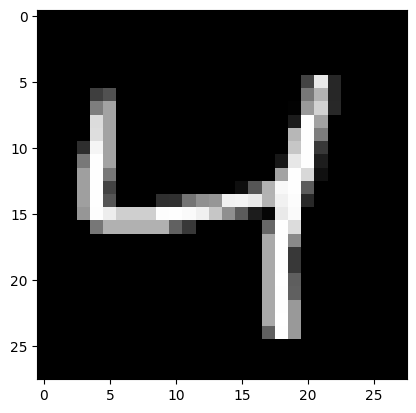

In [13]:
plt.imshow(X[2], cmap="gray")
plt.show()

### Çoklu Görüntülerin Görselleştirilmesi

Veri setinden ilk 9 örneği 3x3'lük bir grid üzerinde görselleştiririz. Her bir alt grafiğin başlığına, o görüntüye ait etiket yazdırılır. Bu, veri setindeki çeşitliliği ve etiketlerin doğruluğunu hızlıca kontrol etmek için yararlıdır.

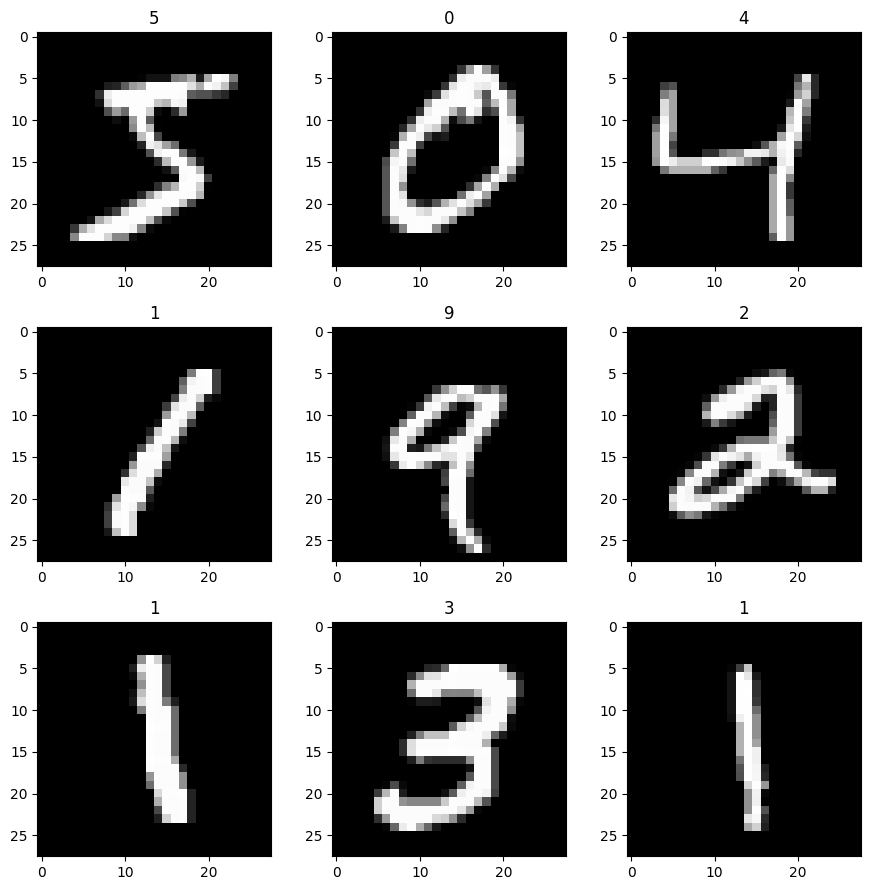

In [14]:
plt.figure(figsize=(9, 9))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.title(str(y[i]))
    plt.imshow(X[i], cmap="gray")

plt.tight_layout()
plt.show()

### NumPy ile Dizi İşlemleri: Fark Alma

İki NumPy dizisi arasındaki eleman bazında farkı gösteren basit bir örnek. Bu, KNN'de iki görüntü arasındaki piksel farklarını hesaplamanın temelini oluşturur.

In [15]:
a = np.array([[1, 3, 2],
              [1, 1, 2]])

b = np.array([[4, 1, 3],
              [2, 1, 2]])
print(a - b)

[[-3  2 -1]
 [-1  0  0]]


### L1 Uzaklığı (Manhattan Mesafesi) Hesabı - Örnek

L1 uzaklığı, iki dizi arasındaki farkların mutlak değerlerinin toplamıdır. Bu metrik, özellikle görüntüler arasındaki benzerlik veya farklılığı ölçmek için kullanılır. Manhattan mesafesi olarak da bilinir, çünkü bu mesafe, bir şehirdeki bloklar arasındaki mesafeyi ölçmek için kullanılan yönteme benzer.

#### Matematiksel Tanım

İki vektör \( a \) ve \( b \) arasındaki L1 uzaklığı şu şekilde hesaplanır:

\[
L1(a, b) = \sum_{i=1}^{n} |a_i - b_i|
\]

Burada:
- \( a \) ve \( b \), karşılaştırılan iki vektördür.
- \( n \), vektörlerin boyutudur.
- \( |a_i - b_i| \), her bir eleman arasındaki farkın mutlak değeridir.

#### Görüntüler İçin L1 Uzaklığı

Görüntüler, genellikle iki boyutlu matrisler olarak temsil edilir. Bu durumda, L1 uzaklığı, iki matris arasındaki tüm elemanların farklarının mutlak değerlerinin toplamı olarak hesaplanır:

\[
L1(A, B) = \sum_{i=1}^{h} \sum_{j=1}^{w} |A_{i,j} - B_{i,j}|
\]

Burada:
- \( A \) ve \( B \), karşılaştırılan iki görüntüdür.
- \( h \) ve \( w \), görüntülerin yüksekliği ve genişliğidir.
- \( A_{i,j} \) ve \( B_{i,j} \), görüntülerin \( (i, j) \) konumundaki piksel değerleridir.

#### Örnek Kullanım

L1 uzaklığı, el yazısı rakamların görüntülerini karşılaştırmak için kullanılabilir. Örneğin, MNIST veri setindeki iki görüntü arasındaki L1 uzaklığı, bu görüntülerin ne kadar benzer olduğunu ölçmek için kullanılabilir. Daha düşük bir L1 uzaklığı, görüntülerin daha benzer olduğunu gösterir.

Bu metrik, KNN algoritmasında sorgu görüntüsü ile eğitim setindeki görüntüler arasındaki uzaklıkları hesaplamak için yaygın olarak kullanılır.

In [16]:
np.sum(np.abs(a - b))

np.int64(7)

### Uzaklık Fonksiyonlarının Tanımlanması

KNN algoritmasında iki veri noktası (bu durumda iki görüntü) arasındaki benzerliği veya farklılığı ölçmek için uzaklık metrikleri kullanılır. Burada iki yaygın metrik tanımlanmıştır:

1.  **`l1_distance` (Manhattan Mesafesi):** İki görüntü arasındaki piksel farklarının mutlak değerlerinin toplamı. Şehir blokları arasındaki mesafe gibi düşünülebilir.
    $$ L1(a, b) = \sum_{i} |a_i - b_i| $$
2.  **`l2_distance` (Öklid Mesafesi):** İki görüntü arasındaki piksel farklarının karelerinin toplamının karekökü. İki nokta arasındaki düz çizgi mesafesidir.
    $$ L2(a, b) = \sqrt{\sum_{i} (a_i - b_i)^2} $$

Bu fonksiyonlar, daha sonra KNN sınıfında kullanılacaktır.

In [17]:
def l1_distance(img_a, img_b):
    fark = img_a - img_b
    mutlak = np.abs(fark)
    toplam_fark = np.sum(mutlak)
    return toplam_fark


def l2_distance(img_a, img_b):
    fark = img_a - img_b
    karesi = fark ** 2
    toplam = np.sum(karesi)
    karekok = np.sqrt(toplam)
    return karekok


a = np.array([[1, 1],
              [1, 1]])

b = np.array([[2, 2],
              [2, 2]])

dist = l1_distance(a, b)
print(dist)
dist = l2_distance(a, b)
print(dist)

4
2.0


### `collections.Counter` Kullanımı

`Counter`, bir listedeki elemanların kaç kez tekrar ettiğini sayar. `most_common()` metodu, en sık görünen elemanları ve frekanslarını bir liste olarak döndürür. `[0][0]` ifadesiyle en sık görünen elemanın kendisini alırız. Bu, KNN'de en yakın komşuların sınıfları arasında en popüler olanı bulmak için kullanılır.

In [18]:
c = Counter([2, 1, 2, 2, 1, 3])
c.most_common()[0][0]

2

### KNN için Sorgu Görüntüsü Seçimi

Sınıflandırmak istediğimiz bir görüntüyü (sorgu görüntüsü) veri setinden seçeriz. Bu örnekte 13. indeksteki görüntü seçilmiştir. Görüntüyü ve gerçek etiketini görselleştiririz.

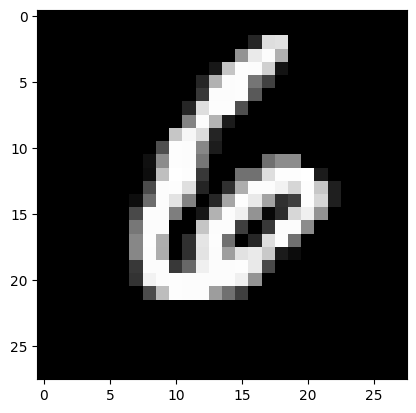

6


In [19]:
resim_idx = 13
query_img = X[resim_idx]
plt.imshow(query_img, cmap="gray")
plt.show()
print(y[resim_idx])

### Uzaklıkların Hesaplanması

Sorgu görüntüsünün, eğitim setindeki (`X`) **her bir** görüntüye olan uzaklığını (bu örnekte L1 uzaklığı kullanılarak) hesaplarız ve sonuçları `uzakliklar` listesinde saklarız. Bu, KNN'nin en hesaplama yoğun adımıdır, çünkü sorgu görüntüsünü tüm eğitim verisiyle karşılaştırmayı gerektirir.

In [20]:
uzakliklar = []
for img in X:
    uzaklik = l1_distance(img, query_img)
    uzakliklar.append(uzaklik)

print(uzakliklar[:10])

[np.uint64(29034), np.uint64(31068), np.uint64(27608), np.uint64(25556), np.uint64(26515), np.uint64(29830), np.uint64(22483), np.uint64(36096), np.uint64(19551), np.uint64(26997)]


### `np.argsort` Kullanımı

`np.argsort`, bir dizinin elemanlarını küçükten büyüğe sıraladığımızda orijinal indekslerin nasıl bir sırada olacağını döndürür. Örneğin, `[3, 1, -1, 7, 2]` dizisi sıralandığında `[-1, 1, 2, 3, 7]` olur. Bu sıralanmış dizideki elemanların orijinal dizideki indeksleri `[2, 1, 4, 0, 3]`'tür. KNN'de, hesaplanan uzaklıkları sıralayarak en yakın komşuların indekslerini bulmak için kullanılır.

In [21]:
np.argsort([3, 1, -1, 7, 2])

array([2, 1, 4, 0, 3])

### En Yakın Komşuların Bulunması

1. **Uzaklıkların Sıralanması:** 
    - `np.argsort(uzakliklar)` fonksiyonu, uzaklıkları küçükten büyüğe sıralar ve bu sıralamaya göre orijinal dizideki indeksleri döndürür. Bu sayede, sorgu görüntüsüne en yakın olan görüntülerin indekslerini elde ederiz.

2. **K Değeri Nedir?**
    - `K`, KNN algoritmasında kaç tane en yakın komşuya bakacağımızı belirleyen bir parametredir. Örneğin, `K=3` seçersek, sorgu görüntüsüne en yakın 3 komşuyu dikkate alırız.
    - K değeri, modelin performansını etkileyen kritik bir hiperparametredir:
      - **Küçük K Değerleri:** Model, daha az komşuya bakarak tahmin yapar. Bu, modelin daha hassas olmasını sağlar ancak gürültüye karşı daha duyarlı hale getirir.
      - **Büyük K Değerleri:** Model, daha fazla komşuya bakarak tahmin yapar. Bu, modelin daha genel bir tahmin yapmasını sağlar ancak sınıflar arasındaki sınırların daha az belirgin olmasına neden olabilir.

3. **Kendisi Hariç En Yakın Komşuların Seçilmesi:**
    - `sirali_indeksler[1:K+1]` ifadesi, sıralı indekslerin 1. elemanından başlayarak `K` adet komşuyu seçer. 
    - **Neden 1'den Başlıyoruz?**
      - 0. indeks, sorgu görüntüsünün kendisine olan uzaklığıdır (bu uzaklık her zaman 0'dır). Bu nedenle, sorgu görüntüsünü hariç tutarız ve kendisi dışındaki en yakın `K` komşuyu seçeriz.

4. **Sonuç:**
    - `en_yakin_komsular`, sorgu görüntüsüne en yakın `K` adet görüntünün eğitim setindeki (`X`) indekslerini içerir. Bu indeksler, daha sonra bu komşuların etiketlerini (`y`) almak ve tahmin yapmak için kullanılır.

#### Örnek:
- Uzaklıklar: `[0, 5, 3, 8, 2]`
- `np.argsort(uzakliklar)`: `[0, 4, 2, 1, 3]` (Uzaklık sırasına göre indeksler)
- `K=3` için `sirali_indeksler[1:K+1]`: `[4, 2, 1]` (Kendisi hariç en yakın 3 komşunun indeksleri)

In [42]:
sirali_indeksler = np.argsort(uzakliklar)
en_yakin_komsular = sirali_indeksler[1:4]

### En Yakın Komşuların Görselleştirilmesi

Bulduğumuz en yakın komşulardan birini (örneğin 3. en yakın komşuyu) ve etiketini görselleştiririz. Bu, algoritmanın mantıksal olarak benzer görüntüleri bulup bulmadığını kontrol etmeye yardımcı olur.
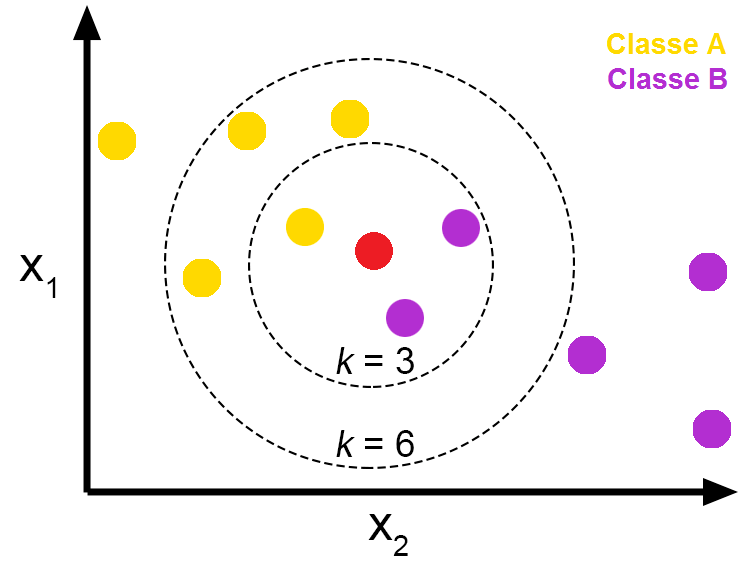


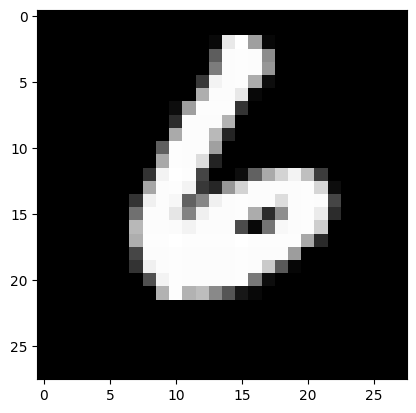

6


In [43]:
resim_idx = 13
plt.imshow(X[en_yakin_komsular[2]], cmap="gray")
plt.show()
print(y[en_yakin_komsular[2]])

### Komşu Sınıflarının Etiketlerinin Alınması

Önceki adımda, sorgu görüntümüze en yakın `K` adet komşu görüntünün eğitim setindeki indekslerini (`en_yakin_komsular`) bulduk. Bu adımda, bu komşuların hangi sınıflara (yani hangi rakamlara) ait olduğunu belirleyeceğiz.

1.  **Amaç:** En yakın komşuların etiketlerini (0-9 arasındaki rakam değerlerini) öğrenmek.
2.  **Yöntem:** `en_yakin_komsular` listesindeki her bir indeks için, tüm eğitim verisinin etiketlerini içeren `y` dizisine başvururuz. Örneğin, `en_yakin_komsular` listesindeki ilk indeks `40157` ise, `y[40157]` ifadesi bize bu komşunun gerçek etiketini (örneğin `6`) verir.
3.  **Uygulama:** Bir döngü kullanarak `en_yakin_komsular` listesindeki her bir komşu indeksi için ilgili etiketi `y` dizisinden alırız.
4.  **Sonuç:** Alınan tüm bu etiketleri `komsu_siniflari` adında yeni bir listede toplarız. Bu liste, sorgu görüntüsüne en yakın komşuların sınıflarını içerir (örneğin, `K=3` ise `[6, 1, 6]` gibi). Bu liste, bir sonraki adımda en popüler sınıfı belirleyerek tahmin yapmak için kullanılacaktır.

In [44]:
komsu_siniflari = []
for komsu in en_yakin_komsular:
    komsu_siniflari.append(y[komsu])

### Tahmin Yapma (Sınıf Belirleme): Çoğunluk Oyu Prensibi

Önceki adımda elde ettiğimiz `komsu_siniflari` listesi, sorgu görüntüsüne en yakın `K` komşunun etiketlerini (örneğin, `K=3` için `[6, 1, 6]` gibi) içerir. KNN algoritmasının temel prensibi, bu komşular arasında **çoğunluk oylaması** yapmaktır. Yani, sorgu görüntüsünün sınıfı, en yakın komşuları arasında en sık görünen sınıf olarak belirlenir.

Bu işlemi gerçekleştirmek için `collections.Counter` nesnesini kullanırız:

1.  **Frekans Sayımı:** `Counter(komsu_siniflari)` komutu, `komsu_siniflari` listesindeki her bir sınıf etiketinin kaç kez tekrar ettiğini sayar. Örneğin, `[6, 1, 6]` listesi için `Counter({6: 2, 1: 1})` gibi bir sonuç üretir. Bu, '6' etiketinin 2 kez, '1' etiketinin ise 1 kez görüldüğünü gösterir.

2.  **En Sık Görüneni Bulma:** `most_common()` metodu, sayılan etiketleri frekanslarına göre büyükten küçüğe doğru sıralar ve `[(etiket, frekans)]` şeklinde bir liste döndürür. Örneğimiz için bu, `[(6, 2), (1, 1)]` olacaktır.

3.  **Tahmini Çıkarma:**
    *   `most_common()[0]` ifadesi, bu sıralı listenin ilk elemanını, yani en yüksek frekansa sahip olan `(etiket, frekans)` çiftini seçer (örneğimizde `(6, 2)`).
    *   `most_common()[0][0]` ifadesi ise bu çiftin ilk elemanını, yani en sık görünen sınıf etiketinin kendisini alır (örneğimizde `6`).

Sonuç olarak, bu en sık tekrar eden etiket (`6`), KNN algoritmasının sorgu görüntüsü için yaptığı **nihai sınıf tahmini** olur.

In [48]:

print(Counter(komsu_siniflari).most_common())
Counter(komsu_siniflari).most_common()[0][0]

[(np.uint8(6), 2), (np.uint8(1), 1)]


np.uint8(6)

### KNN Sınıfının Oluşturulması

KNN algoritmasının adımlarını (uzaklık hesaplama, sıralama, en yakınları bulma, sınıf belirleme) daha organize, yapılandırılmış ve tekrar kullanılabilir bir biçimde uygulamak için bir Python sınıfı (`KNN`) tanımlıyoruz. Bu sınıf, algoritmanın mantığını tek bir yerde toplar.

-   **`__init__(self, distance_fun, K)` (Yapıcı Metot):**
    -   **Amaç:** `KNN` sınıfından yeni bir nesne (örnek) oluşturulduğunda çağrılır ve başlangıç ayarlarını yapar.
    -   **Parametreler:**
        -   `self`: Oluşturulan nesnenin kendisini temsil eder. Sınıf içindeki diğer metotların ve özelliklerin (değişkenlerin) erişimine olanak tanır.
        -   `distance_fun`: İki veri noktası (bu durumda iki görüntü) arasındaki uzaklığı hesaplamak için kullanılacak fonksiyonu belirtir. Bu, `l1_distance` veya `l2_distance` gibi önceden tanımladığımız fonksiyonlardan biri olabilir. Bu parametre sayesinde, KNN nesnesini farklı uzaklık metrikleriyle kolayca kullanabiliriz.
        -   `K`: Algoritmanın kaç tane en yakın komşuyu dikkate alacağını belirleyen pozitif bir tamsayıdır. Bu, modelin performansını etkileyen önemli bir hiperparametredir.
    -   **İşlev:** Verilen `distance_fun` ve `K` değerlerini, nesnenin daha sonra kullanabilmesi için sırasıyla `self.distance_fun` ve `self.K` adlı özelliklerde (instance variables) saklar.

-   **`fit(self, X, y)` (Eğitim Metodu):**
    -   **Amaç:** Modeli eğitim verisiyle "eğitmek". Ancak KNN, "tembel öğrenme" (lazy learning) algoritması olarak sınıflandırılır, yani karmaşık bir model oluşturma veya parametre öğrenme süreci yoktur.
    -   **Parametreler:**
        -   `self`: Nesnenin kendisi.
        -   `X`: Eğitim veri setini içeren NumPy dizisi (örneğin, tüm MNIST eğitim görüntüleri).
        -   `y`: Eğitim verisindeki her bir örneğe karşılık gelen etiketleri (sınıfları) içeren NumPy dizisi (örneğin, MNIST rakam etiketleri).
    -   **İşlev:** Bu metot, aldığı eğitim verisi `X` ve etiketler `y`'yi doğrudan nesnenin `self.X` ve `self.y` özelliklerinde saklar. Esasen, tüm eğitim verisini ezberler. Asıl hesaplamalar ve karşılaştırmalar `predict` metodu çağrıldığında yapılır.

-   **`predict(self, query_img)` (Tahmin Metodu):**
    -   **Amaç:** Daha önce `fit` metoduyla "ezberlenen" eğitim verisini kullanarak, verilen yeni bir sorgu görüntüsünün (`query_img`) sınıfını tahmin etmek.
    -   **Parametreler:**
        -   `self`: Nesnenin kendisi. Bu sayede `fit` ile saklanan `self.X`, `self.y` verilerine ve `__init__` ile ayarlanan `self.distance_fun`, `self.K` parametrelerine erişebilir.
        -   `query_img`: Sınıfı tahmin edilecek olan tek bir görüntü (bir NumPy dizisi).
    -   **İşlev:** Bu metot, daha önce manuel olarak gerçekleştirdiğimiz KNN adımlarını sırasıyla uygular:
        1.  **Uzaklıkları Hesapla:** `self.X` içindeki *her bir* eğitim görüntüsü ile `query_img` arasındaki uzaklığı, `__init__` sırasında belirlenen `self.distance_fun` fonksiyonunu kullanarak hesaplar. Tüm hesaplanan uzaklıkları `uzakliklar` adlı bir listede toplar. Bu adım, özellikle büyük eğitim veri setlerinde (`self.X`'in boyutu büyük olduğunda) hesaplama açısından en maliyetli kısımdır.
        2.  **Uzaklıkları Sırala:** `np.argsort(uzakliklar)` fonksiyonunu kullanarak `uzakliklar` listesini küçükten büyüğe doğru sıralar ve bu sıralamaya karşılık gelen orijinal eğitim verisi indekslerini (`sirali_indeksler`) elde eder. En küçük uzaklığa sahip görüntünün indeksi listenin başında yer alır.
        3.  **En Yakın K Komşuyu Bul:** `sirali_indeksler[1:self.K+1]` ifadesiyle, sıralı indeksler listesinden en yakın `self.K` adet komşunun indeksini seçer. `[1:]` dilimlemesi, sorgu görüntüsünün kendisine olan uzaklığının (her zaman 0'dır ve ilk sırada yer alır) dahil edilmemesini sağlar. Seçilen indeksler `en_yakin_komsular` listesinde saklanır.
        4.  **Komşu Sınıflarını Al:** `en_yakin_komsular` listesindeki her bir indeks için, `self.y` (eğitim etiketleri) dizisinden ilgili komşunun sınıf etiketini alır ve bu etiketleri `komsu_siniflari` adlı yeni bir listede toplar.
        5.  **Çoğunluk Oyu ile Tahmin Yap:** `collections.Counter(komsu_siniflari)` kullanarak `komsu_siniflari` listesindeki her bir sınıf etiketinin frekansını sayar. `most_common()[0][0]` metoduyla en sık görünen (çoğunlukta olan) sınıf etiketini bulur ve bu etiketi sorgu görüntüsü için nihai tahmin olarak döndürür.

Bu sınıf yapısı, KNN algoritmasını modüler hale getirir, kod tekrarını azaltır ve farklı parametrelerle (uzaklık fonksiyonu, K değeri) veya farklı veri setleriyle kolayca yeniden kullanılmasını sağlar.

In [ ]:
class KNN:
    def __init__(self, distance_fun, K):
        self.distance_fun = distance_fun
        self.K = K

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict(self, query_img):
        uzakliklar = []
        for img in self.X:
            uzaklik = self.distance_fun(img, query_img)
            uzakliklar.append(uzaklik)
        sirali_indeksler = np.argsort(uzakliklar)
        en_yakin_komsular = sirali_indeksler[1:self.K+1]
        komsu_siniflari = []
        for komsu in en_yakin_komsular:
            komsu_siniflari.append(y[komsu])

        return Counter(komsu_siniflari).most_common()[0][0]

### KNN Sınıfının Kullanımı ve Test Edilmesi

1.  `KNN` sınıfından bir nesne (`knn`) oluştururuz. Örnek olarak L2 uzaklık fonksiyonunu (`l2_distance`) ve `K=7` değerini kullanıyoruz.
2.  `knn.fit(X, y)` ile modeli (yani veriyi) eğitiyoruz.
3.  Test etmek için bir sorgu görüntüsü seçiyoruz (örneğin 0. indeksteki görüntü).
4.  `knn.predict(query_img)` ile seçilen görüntü için sınıf tahminini yapıyoruz.
5.  Tahmin sonucunu ve orijinal görüntüyü yazdırarak sonucu kontrol ediyoruz.

4


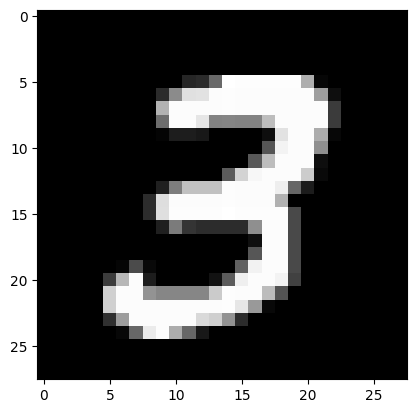

In [61]:
resim_idx = 7
knn = KNN(l2_distance, 7)
knn.fit(X, y)
query_img = X[resim_idx]
sonuc = knn.predict(query_img)
print(sonuc)
plt.imshow(X[resim_idx], cmap="gray")
plt.show()

# Why Normalization Helps KNN Performance

Normalizing the data (dividing pixel values by 255 to scale them to [0-1] range) significantly improved the KNN classifier's performance for several important reasons:

## 1. Equal Importance to All Features

When using raw pixel values (0-255):
- High-valued pixels dominate the distance calculations
- Dark areas (low values) contribute little to the similarity metric

After normalization, all pixels have proportional influence on the distance calculation regardless of their intensity.

## 2. Balanced Distance Calculations

Without normalization:
- A difference of 10 in bright areas (e.g., 240 vs 250) has the same impact as a difference of 10 in dark areas (e.g., 5 vs 15)
- However, the relative difference is much larger in the dark areas

Normalization ensures distances reflect proportional differences rather than absolute differences.

## 3. Improved Numerical Stability

Large numbers can lead to:
- Floating point precision issues
- Potential overflow in distance calculations, especially with L2 distance which involves squaring values

## 4. Better Handling of Outliers

Extreme pixel values (very bright spots) can disproportionately affect distance calculations. Normalization reduces their outsized influence.

## 5. Faster Convergence

Normalized data often allows distance calculations to be more efficient and stable, improving both accuracy and computational performance.

## Code Example of the Improvement

```python
# Without normalization - poor performance
knn = KNN(l2_distance, 7)
knn.fit(X, y)  # Raw values 0-255
query_img = X[resim_idx]
result = knn.predict(query_img)

# With normalization - better performance
X_normalized = X / 255.0  # Scale to [0-1]
knn = KNN(l2_distance, 7) 
knn.fit(X_normalized, y)
query_img = X[resim_idx]  # Don't forget to normalize query too!
result = knn.predict(query_img)
```

This normalization technique is a standard preprocessing step in many machine learning algorithms, not just KNN.

8


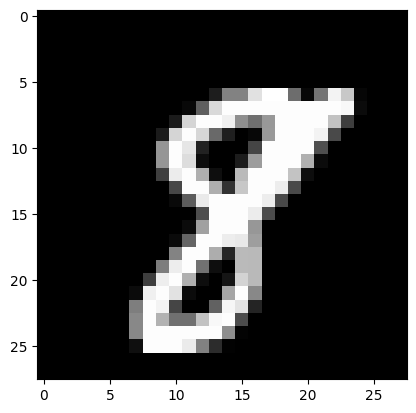

In [66]:
resim_idx = 55
X_normalized = X / 255.0
knn = KNN(l2_distance, 7)
knn.fit(X_normalized, y)
query_img = X[resim_idx]
sonuc = knn.predict(query_img)
print(sonuc)
plt.imshow(X[resim_idx], cmap="gray")
plt.show()

### Farklı Parametrelerle KNN Testi

Bu hücrede, farklı bir sorgu görüntüsü ve farklı parametrelerle KNN algoritmasını test ederiz. Örneğin, L1 uzaklık fonksiyonunu ve `K=5` değerini kullanarak tahmin yaparız.